In [106]:
%load_ext autoreload
%autoreload 2
import main
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Parameters

In [107]:
rho = 1
#d_list = [100, 200, 400]
d_list = [100, 200, 400, 800, 1600]
num_runs = 10
num_epochs = 50
sigma2 = 0.01

In [108]:
# Different covariance structures
cov_structures = {
    "identity": lambda d: np.eye(d),
    "diag_decreasing": lambda d: np.diag(np.linspace(1, 0.1, d)),
    "diag_increasing": lambda d: np.diag(np.linspace(0.1, 2, d)),
    "toeplitz": lambda d: np.array([[0.9**abs(i-j) for j in range(d)] for i in range(d)]),
    "low_rank": lambda d: (np.random.randn(d, 5) @ np.random.randn(5, d)),
    "max_neq_avg" : lambda d: main.diagonal_spike_cov(d)
}

## Figuring order of quantities empirically

We must find the size of some terms in order to determine $\gamma(d)$

In [109]:
for d in d_list:
    print(main.compute_first_term(d, d, 1/d * np.eye(d), sigma2, 1) * d)
    

3.5985320891438626
6.401227319420144
3.6325651056414068
3.8238493784050256
4.180881800319986


This suggests that $|| \nabla \hat{R}(\theta) ||_2^2$ grows in $O(\frac1d)$

In [110]:
for d in d_list:
    print(main.compute_second_term(d, d, 1/d * np.eye(d), sigma2, 1) * d**2)

15.297436562540122
9.445572483397722
10.942213214628419
9.264746266098586
10.877502651374755


This suggests that $ \nabla \hat{R} (\theta_{t-1})^{\top} H \nabla \hat{R} (\theta_{t-1}) $ grows in $O(\frac1{d^2})$

In [111]:
for d in d_list:
    print(main.compute_third_term_sgd(d, d, 1/d * np.eye(d), sigma2, 1) * d)

3.2871043897353998
3.8838092183606814
4.016370629890622
4.401882212941882
4.0468405754065655


## Experiment 1 : Figuring out scaling on $\gamma$ in small batch SGD

### Effect of $\sigma^2$

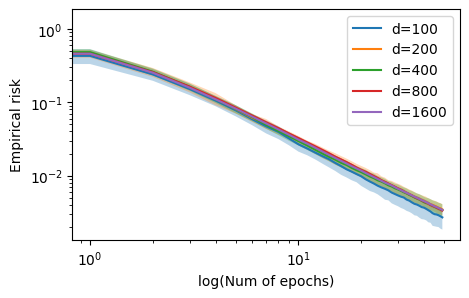

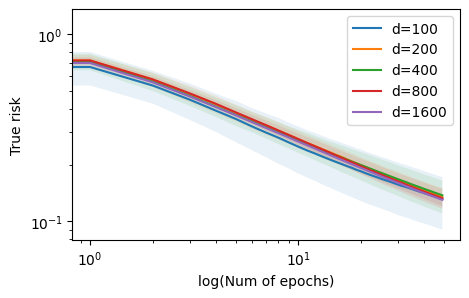

In [112]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:1, sigma_hat=cov_structures["identity"], step_type="max")

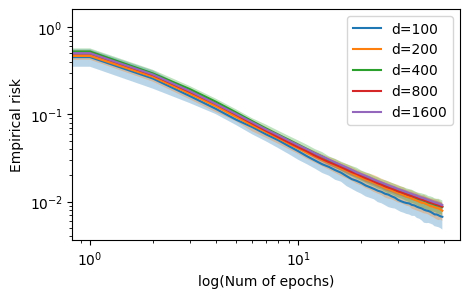

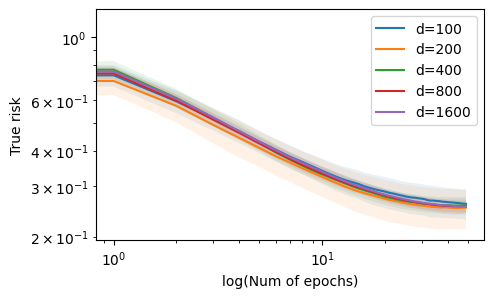

In [113]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2*10, main.run_sgd, gamma=lambda d:1, sigma_hat=cov_structures["identity"], step_type="max") 

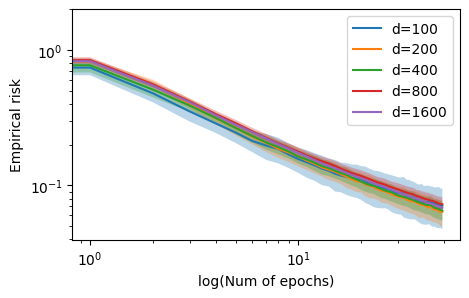

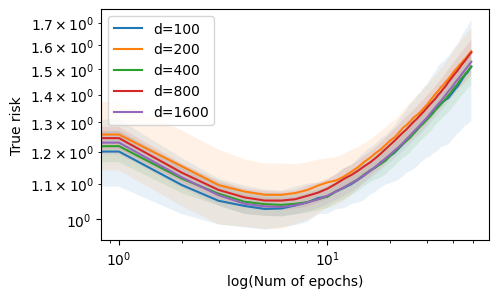

In [114]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2*100, main.run_sgd, gamma=lambda d:1, sigma_hat=cov_structures["identity"], step_type="max") 

### Without optimizing for the absolute cst

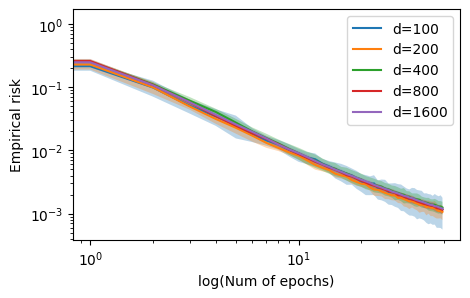

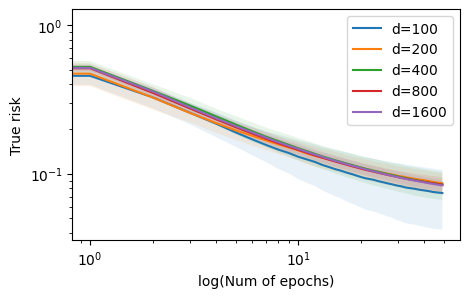

In [115]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:1, sigma_hat=cov_structures["identity"]) 

### Setting the absolute constant to $ \frac{1}{\lambda_{max} (A^T A)} $

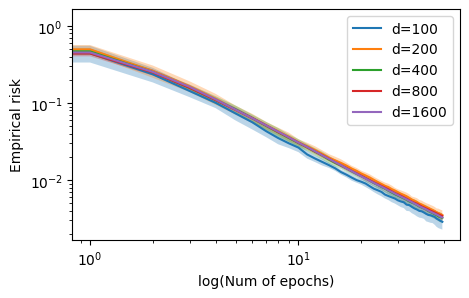

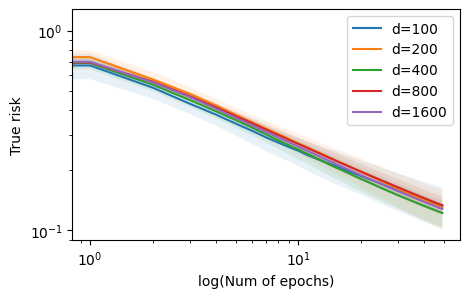

In [116]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:1, sigma_hat=cov_structures["identity"], step_type="max") 

### Setting the absolute constant to $ \frac{1}{\lambda_{avg} (A^T A)} $

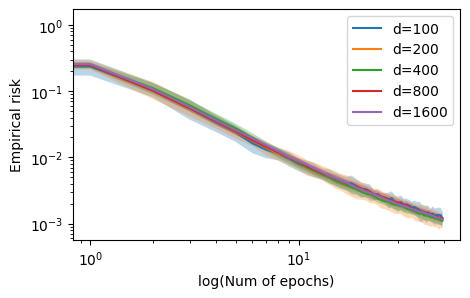

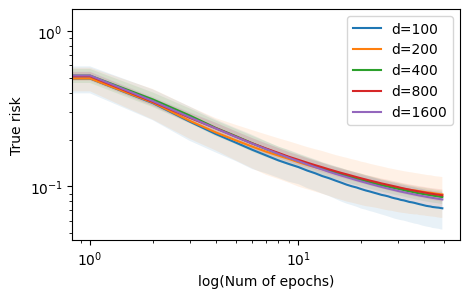

In [117]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:1, sigma_hat=cov_structures["identity"], step_type="avg")

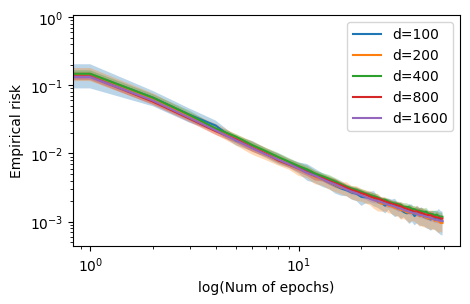

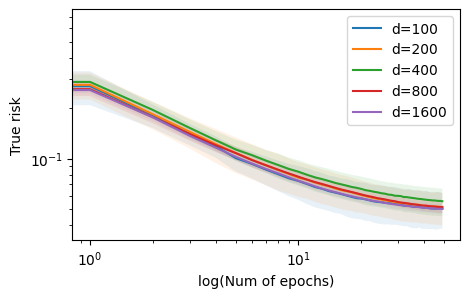

In [118]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:1, sigma_hat=cov_structures["diag_decreasing"], step_type="avg") 

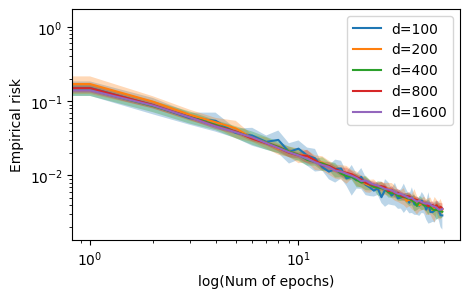

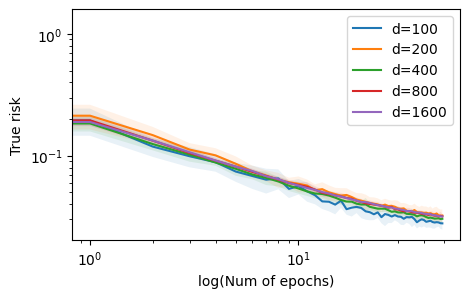

In [119]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:1, sigma_hat=cov_structures["toeplitz"], step_type="avg") 

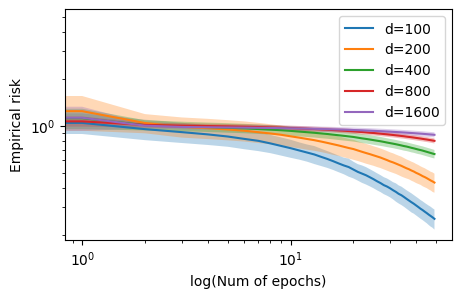

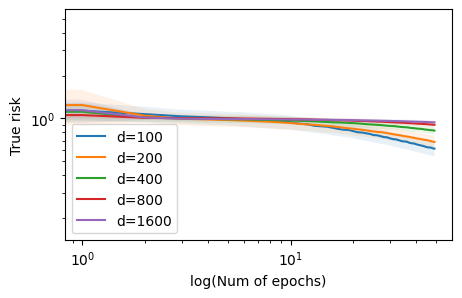

In [120]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:1, sigma_hat=cov_structures["max_neq_avg"], step_type="max") 

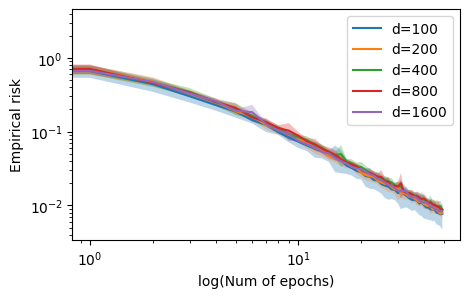

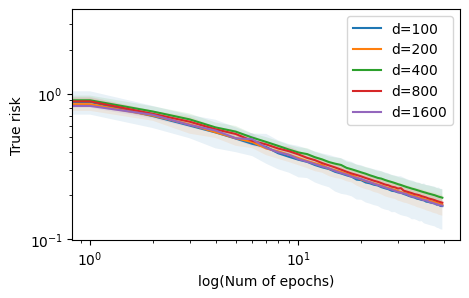

In [121]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:1/4, sigma_hat=cov_structures["max_neq_avg"], step_type="avg") 

## Experiment 2 : Effect of randomness in SGD

### Single shuffle sgd

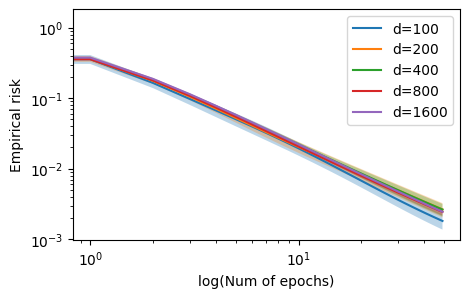

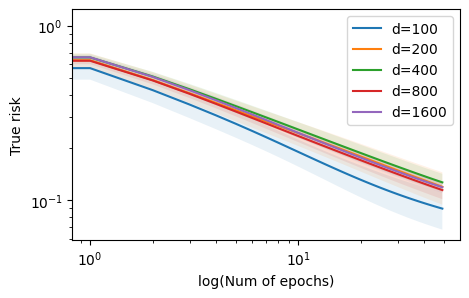

In [122]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.single_suffle_sgd, gamma=lambda d:1, sigma_hat=cov_structures["identity"], step_type="max") 

### Multiple shuffle sgd

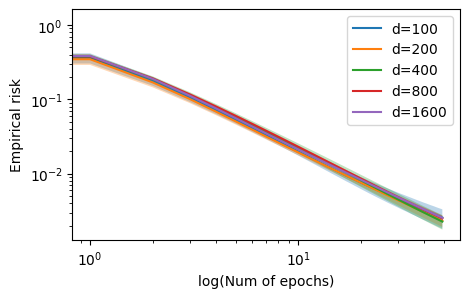

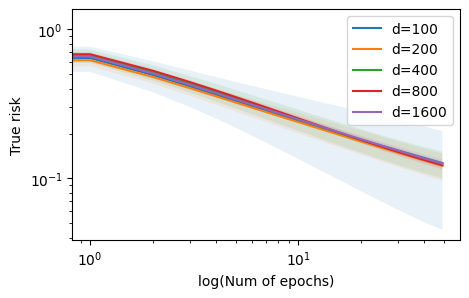

In [123]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.multiple_shuffle_sgd, gamma=lambda d:1, sigma_hat=cov_structures["identity"], step_type="max") 

## Experiment 3 : SGD with momentum

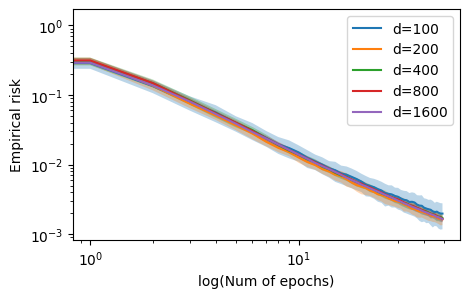

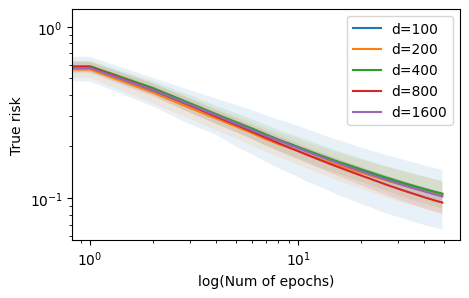

In [124]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_momentum_fixed_delta, gamma=lambda d:1, sigma_hat=cov_structures["identity"], step_type="max")

## Experiment 4 : Small vs large batch sizes

### Full batch $ ( \left |B| = n^1 \right )$ 

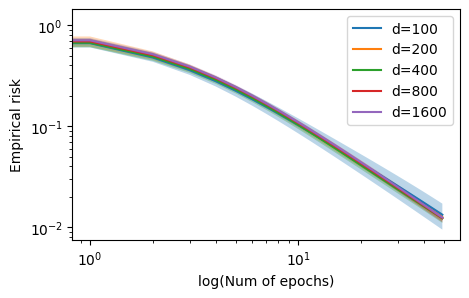

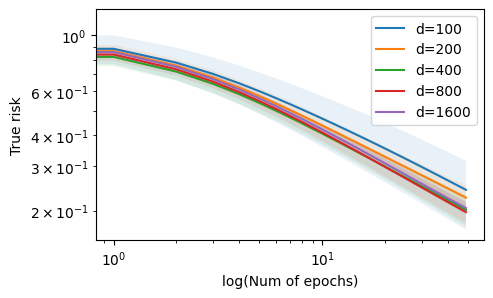

In [125]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_batch, gamma=lambda d:1/3 * d, sigma_hat=cov_structures["identity"], batch_size=lambda n:n, step_type="max")

### $\eta=0.8$ regime $ ( \left |B| = n^{0.8} \right )$ 

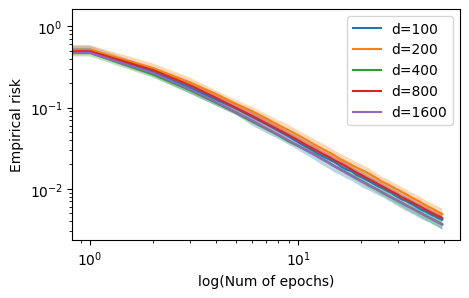

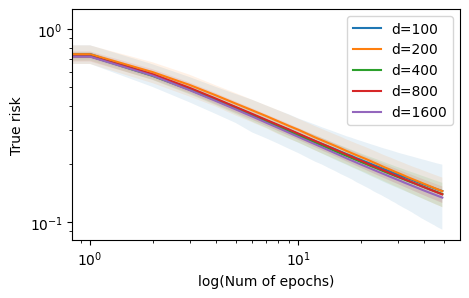

In [126]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_batch, gamma=lambda d: d**0.8, sigma_hat=cov_structures["identity"], batch_size=lambda n:int(n**0.8), step_type= "max")

### $\eta=0.6$ regime $ ( \left |B| = n^{0.6} \right )$ 

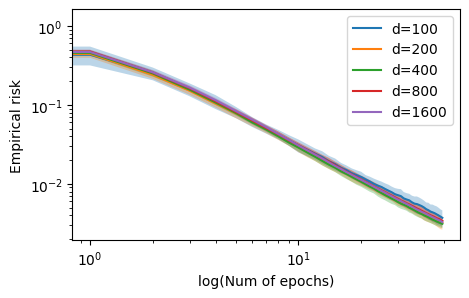

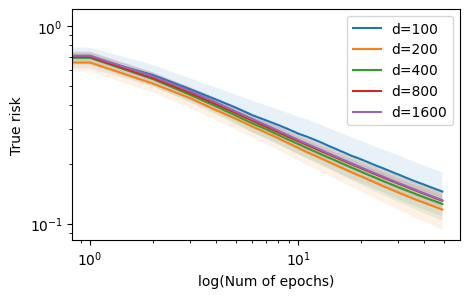

In [127]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_batch, gamma=lambda d:d**0.6, sigma_hat=cov_structures["identity"], batch_size=lambda n:int(n**0.6), step_type= "max")

### $\eta=0.4$ regime $ ( \left |B| = n^{0.4} \right )$ 

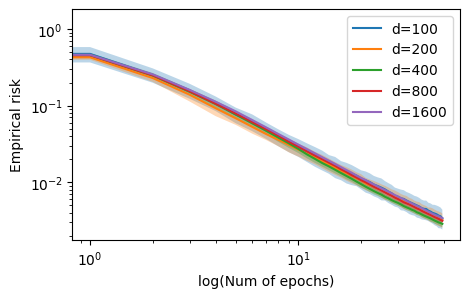

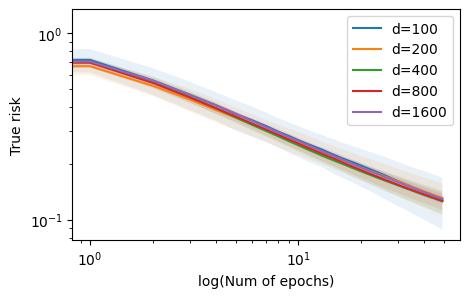

In [128]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_batch, gamma=lambda d:d**0.4, sigma_hat=cov_structures["identity"], batch_size=lambda n:int(n**0.4), step_type= "max")

### $\eta=0.2$ regime $ ( \left |B| = n^{0.2} \right )$ 

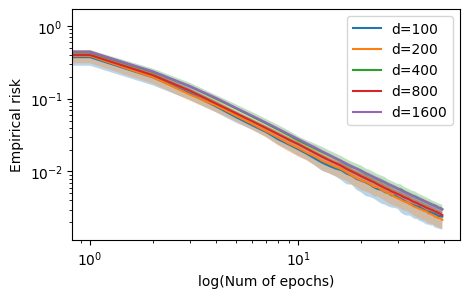

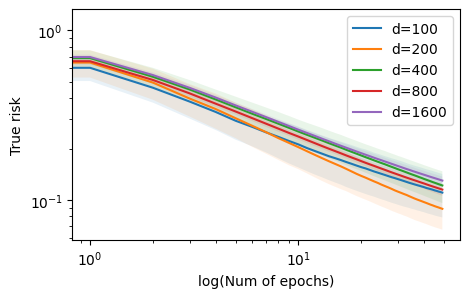

In [129]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_batch, gamma=lambda d:d**0.2, sigma_hat=cov_structures["identity"], batch_size=lambda n:int(n**0.2), step_type= "max")

## Experiment 4 Optional Experiment: Small vs large batch sizes with momentum

### $\xi=0.2$ regime $ ( \left |B| = 0.2n \right )$ 

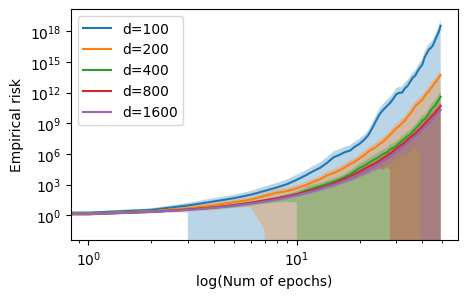

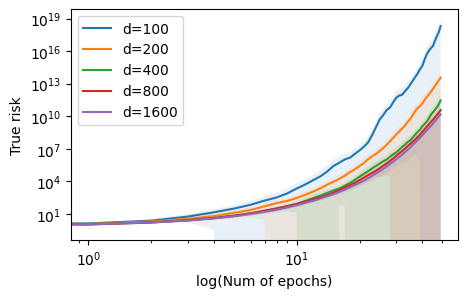

In [135]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_momentum_batch_fixed_delta, gamma=lambda d:d**1, xi = 0.2, sigma_hat=cov_structures["identity"], step_type= "max")

### $\xi=0.4$ regime $ ( \left |B| = 0.4n \right )$ 

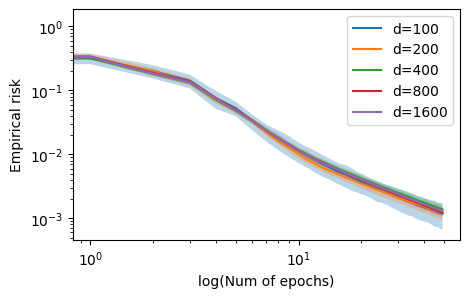

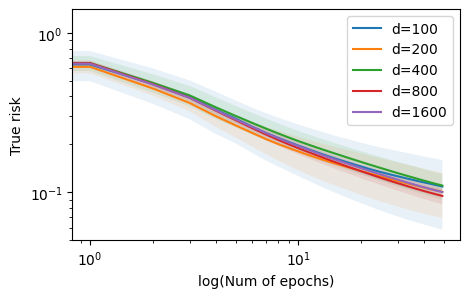

In [136]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_momentum_batch_fixed_delta, gamma=lambda d:d**1, xi = 0.8, sigma_hat=cov_structures["identity"], step_type= "max")

### $\xi=0.5$ regime $ ( \left |B| = 0.5n \right )$ 

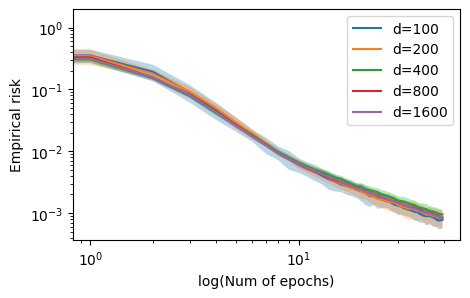

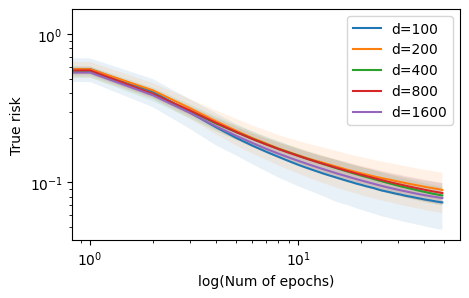

In [137]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_momentum_batch_fixed_delta, gamma=lambda d:d**1, xi = 0.5, sigma_hat=cov_structures["identity"], step_type= "max")

### $\xi=0.6$ regime $ ( \left |B| = 0.6n \right )$ 

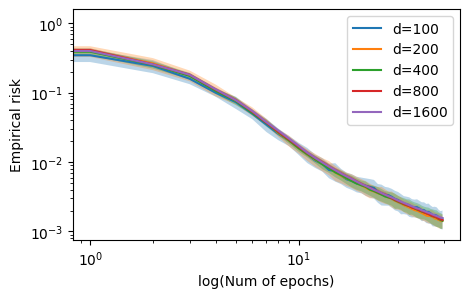

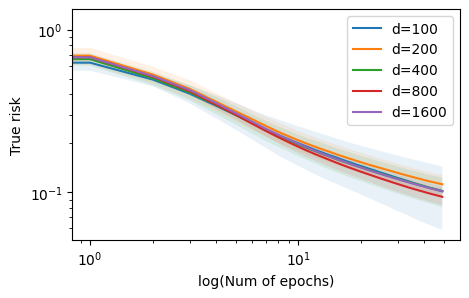

In [138]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_momentum_batch_fixed_delta, gamma=lambda d:d**1, xi = 0.6, sigma_hat=cov_structures["identity"], step_type= "max")

### $\xi=0.8$ regime $ ( \left |B| = 0.8n \right )$ 

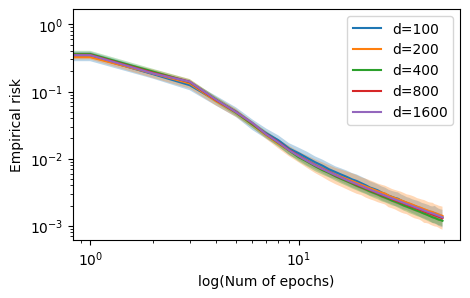

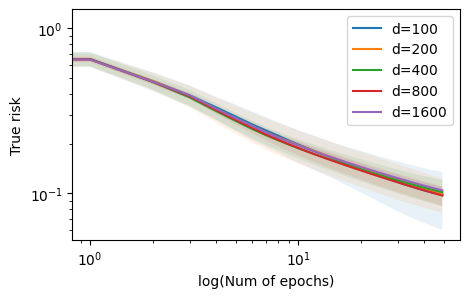

In [139]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_momentum_batch_fixed_delta, gamma=lambda d:d**1, xi = 0.8, sigma_hat=cov_structures["identity"], step_type= "max")

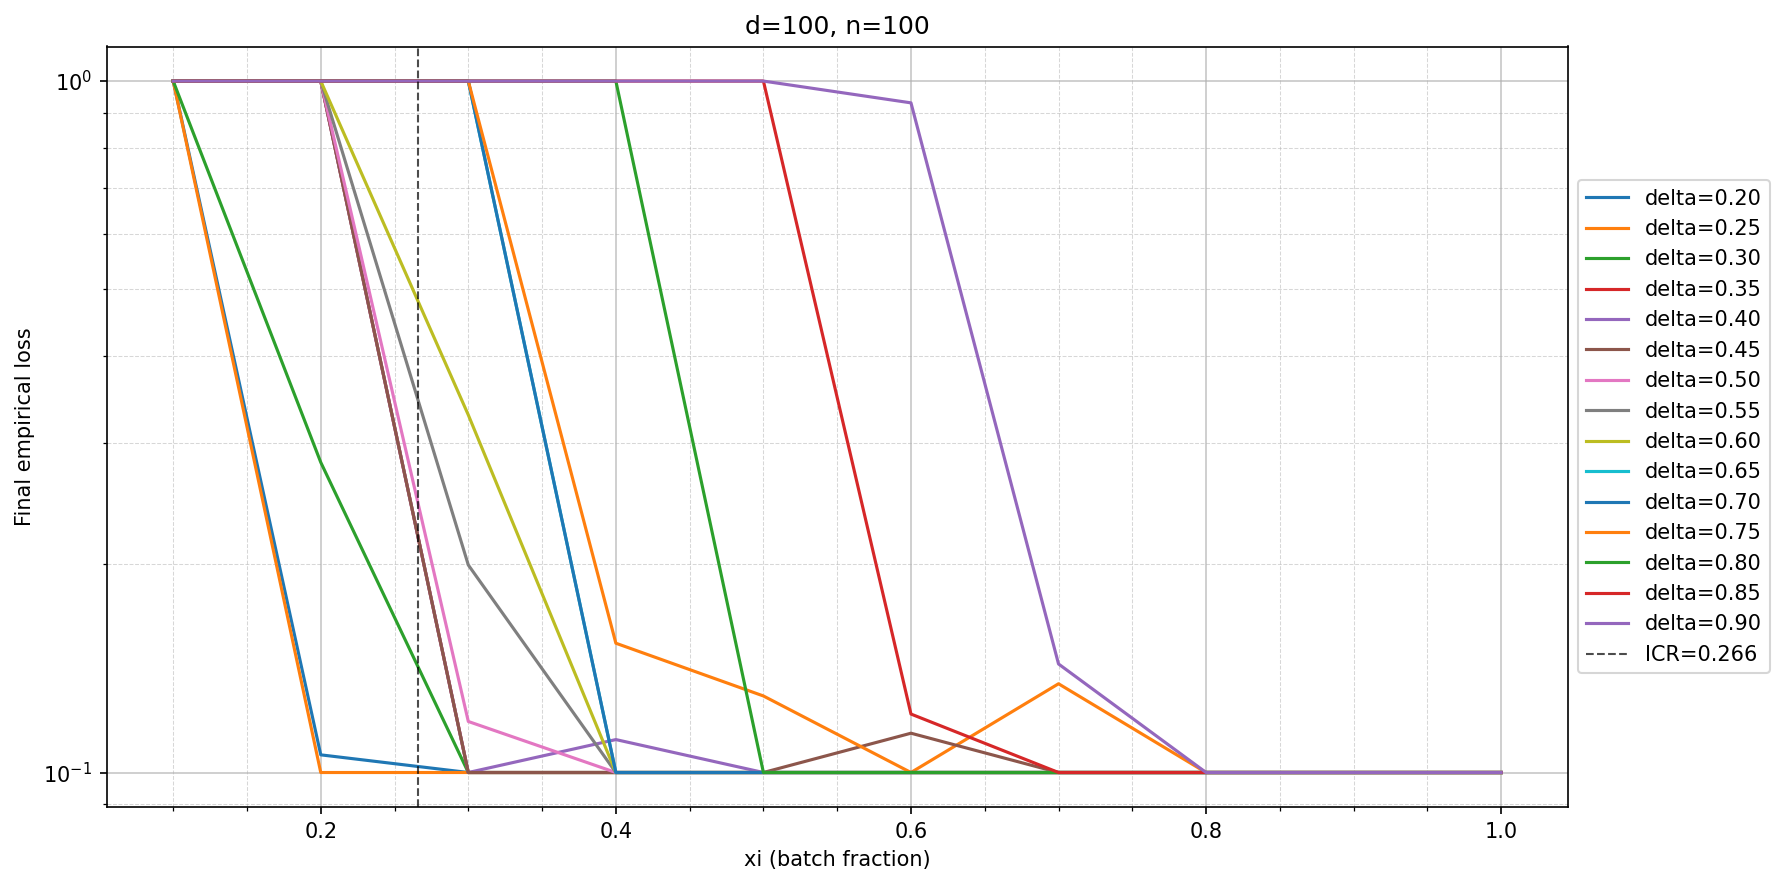

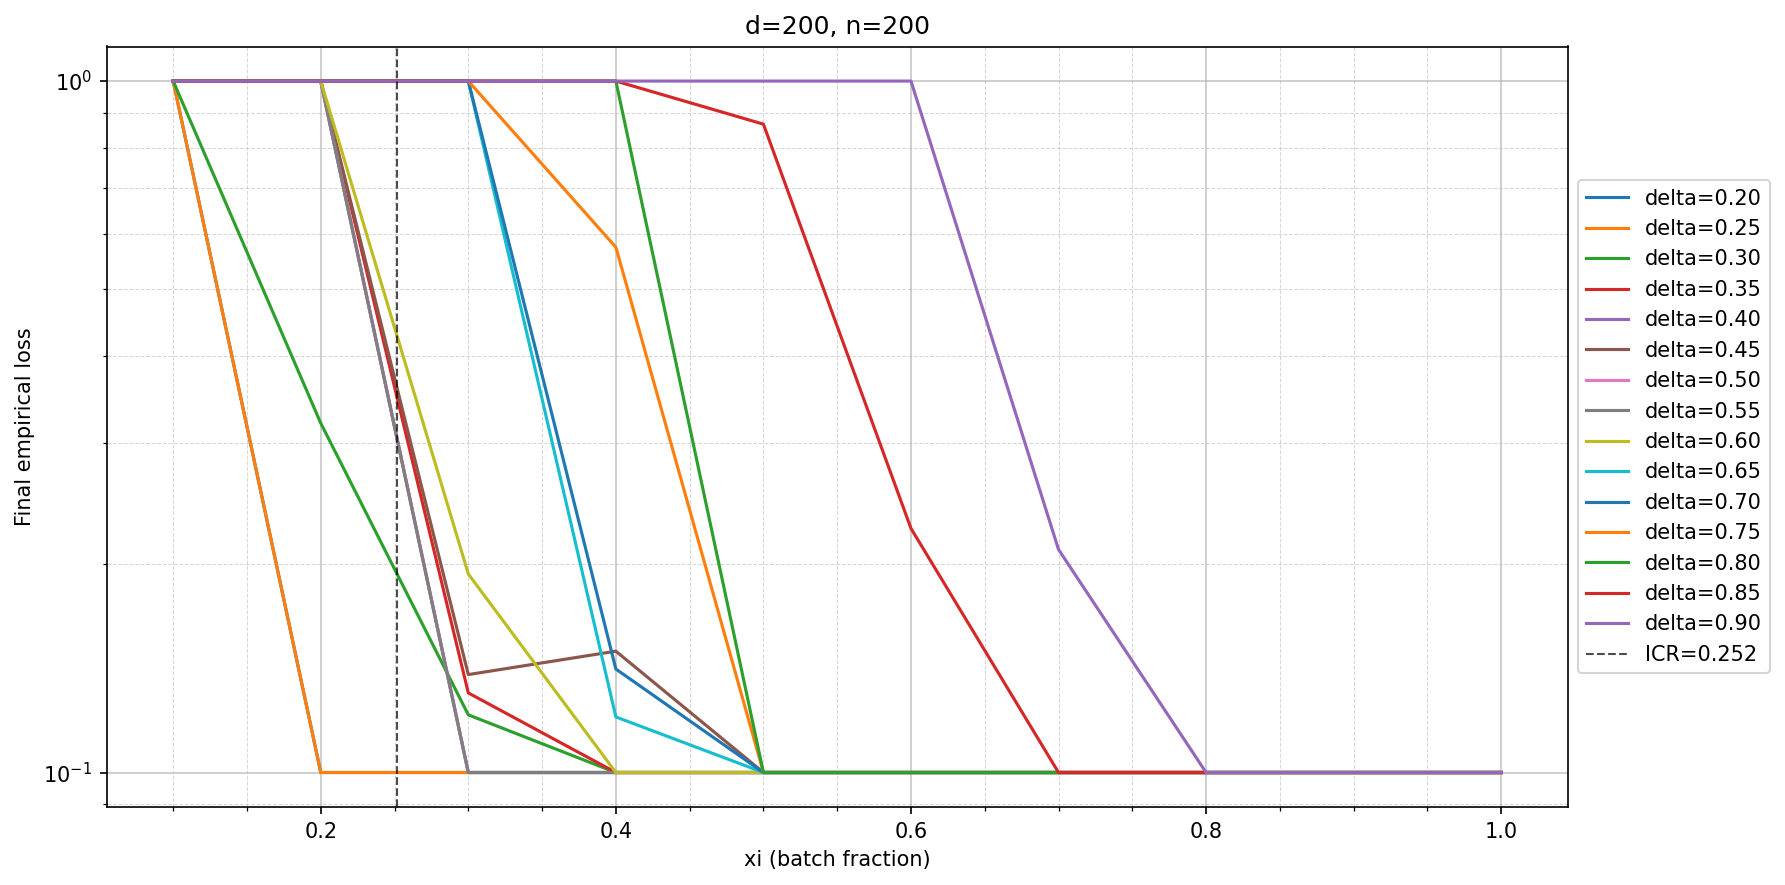

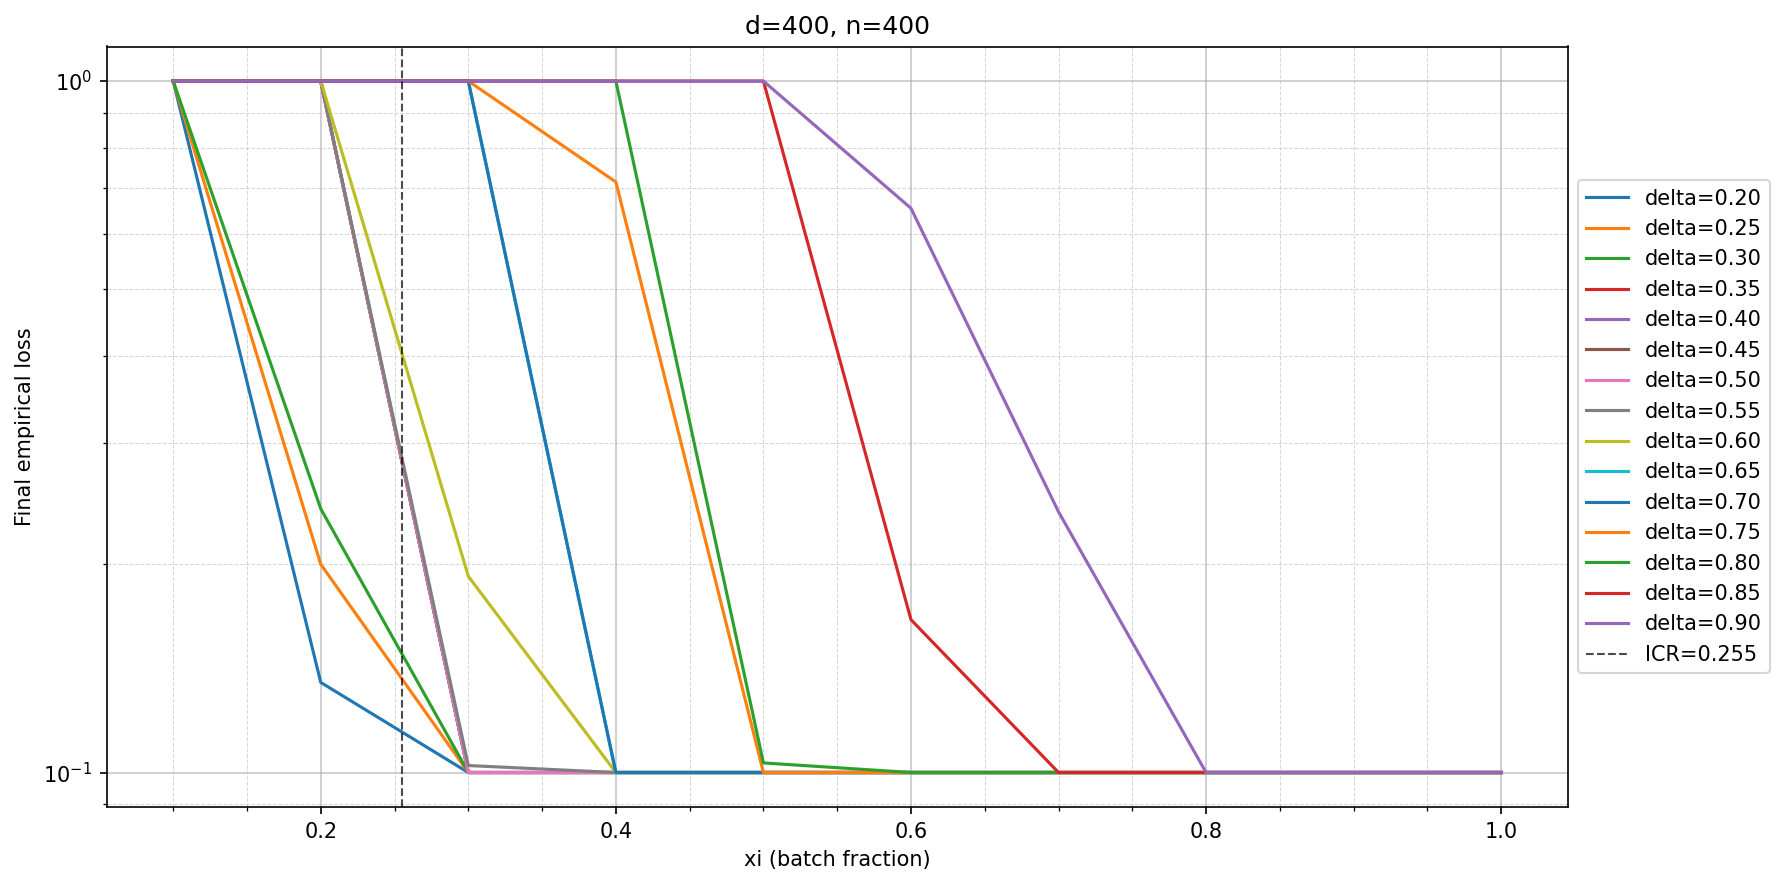

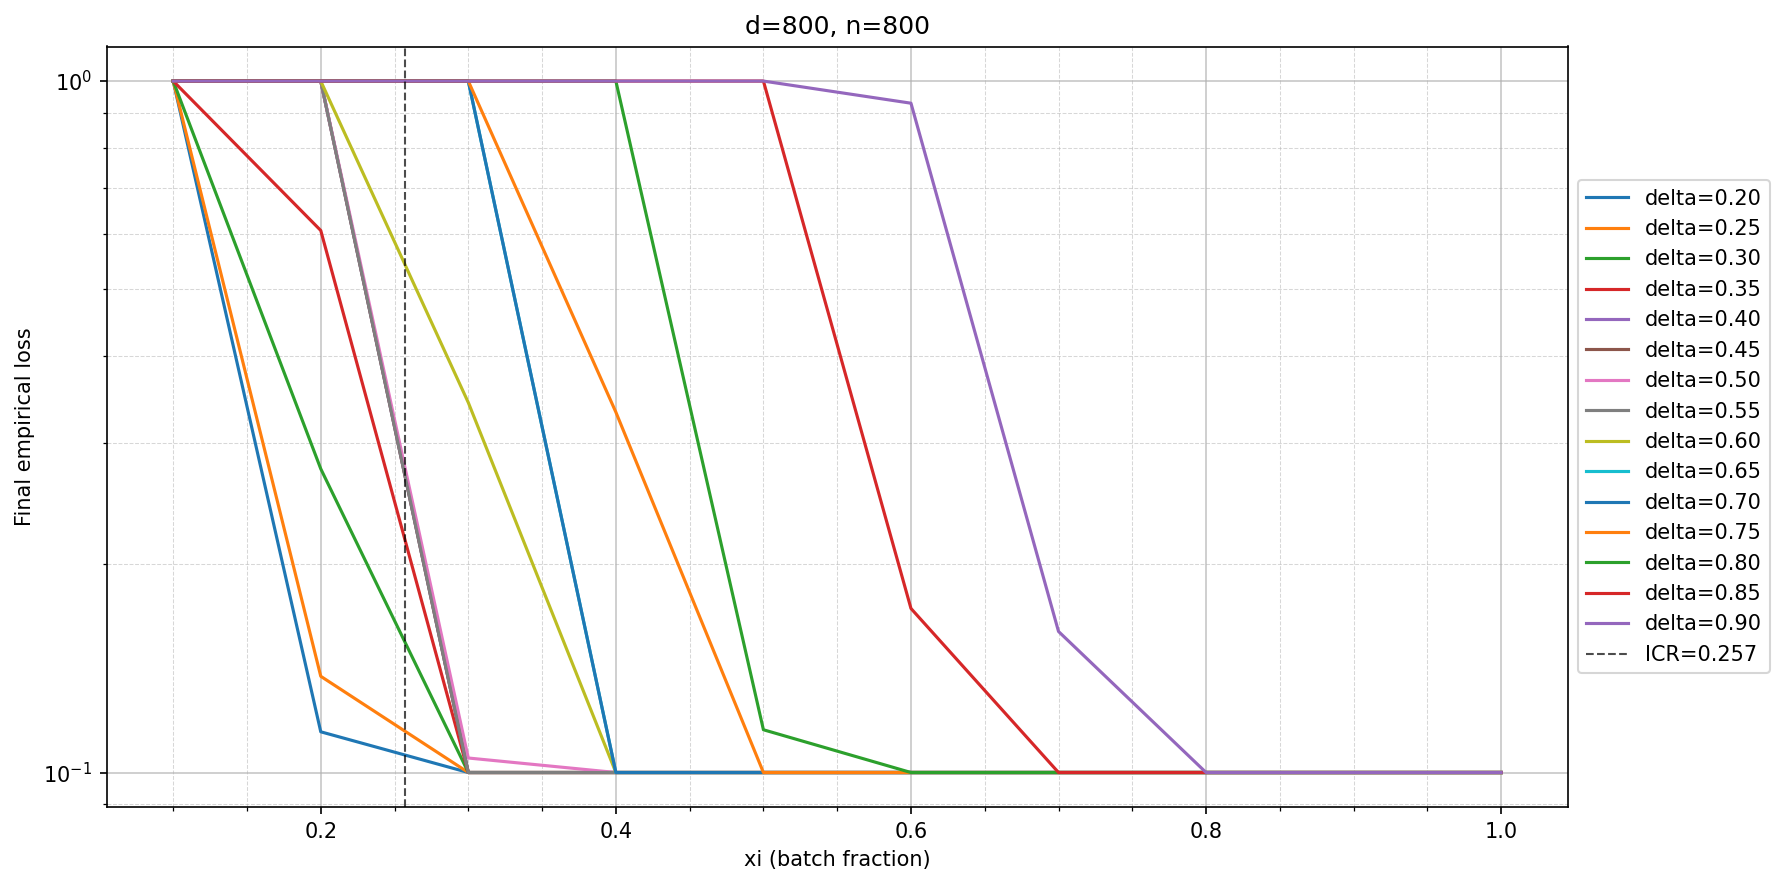

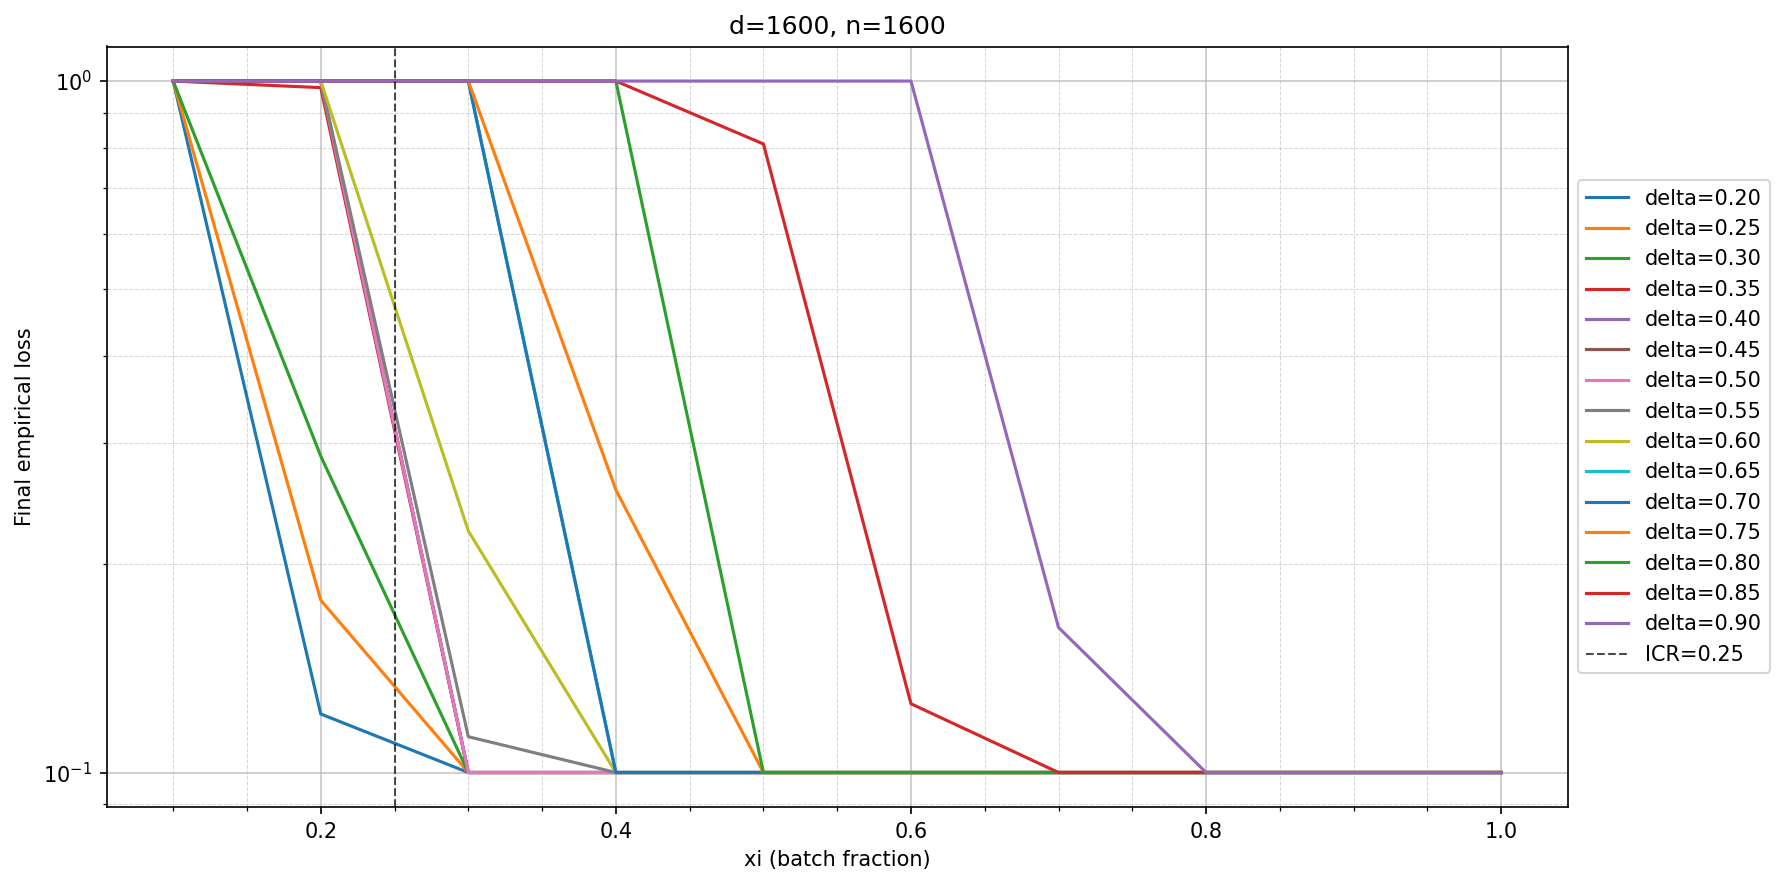

In [140]:
#d_list = [100]
delta_list = np.linspace(0.2, 0.9, 15)  # 15 values from 0.2 to 0.9
xi_list = np.linspace(0.1, 1.0, 10)     # 50 values from 0.1 to 1.0
main.estimate_threshold(
    d_list=d_list,
    delta_list=delta_list,
    xi_list=xi_list,
    rho=rho,
    num_epochs=num_epochs,
    gamma=lambda d: d,
    step_type="max"
)

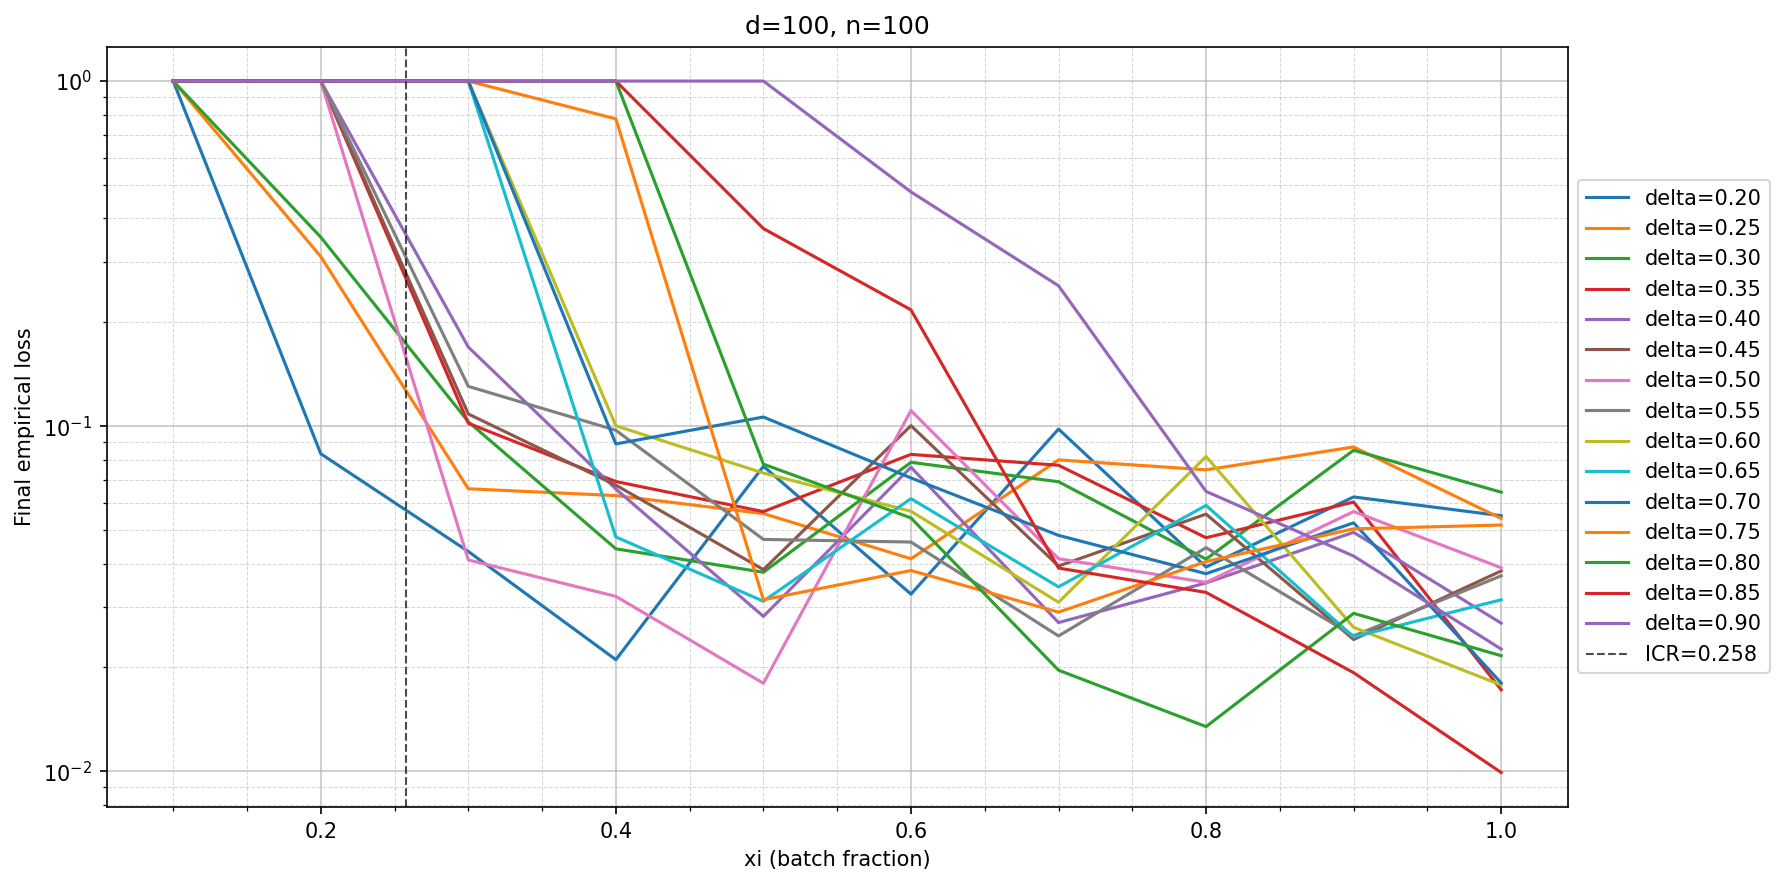

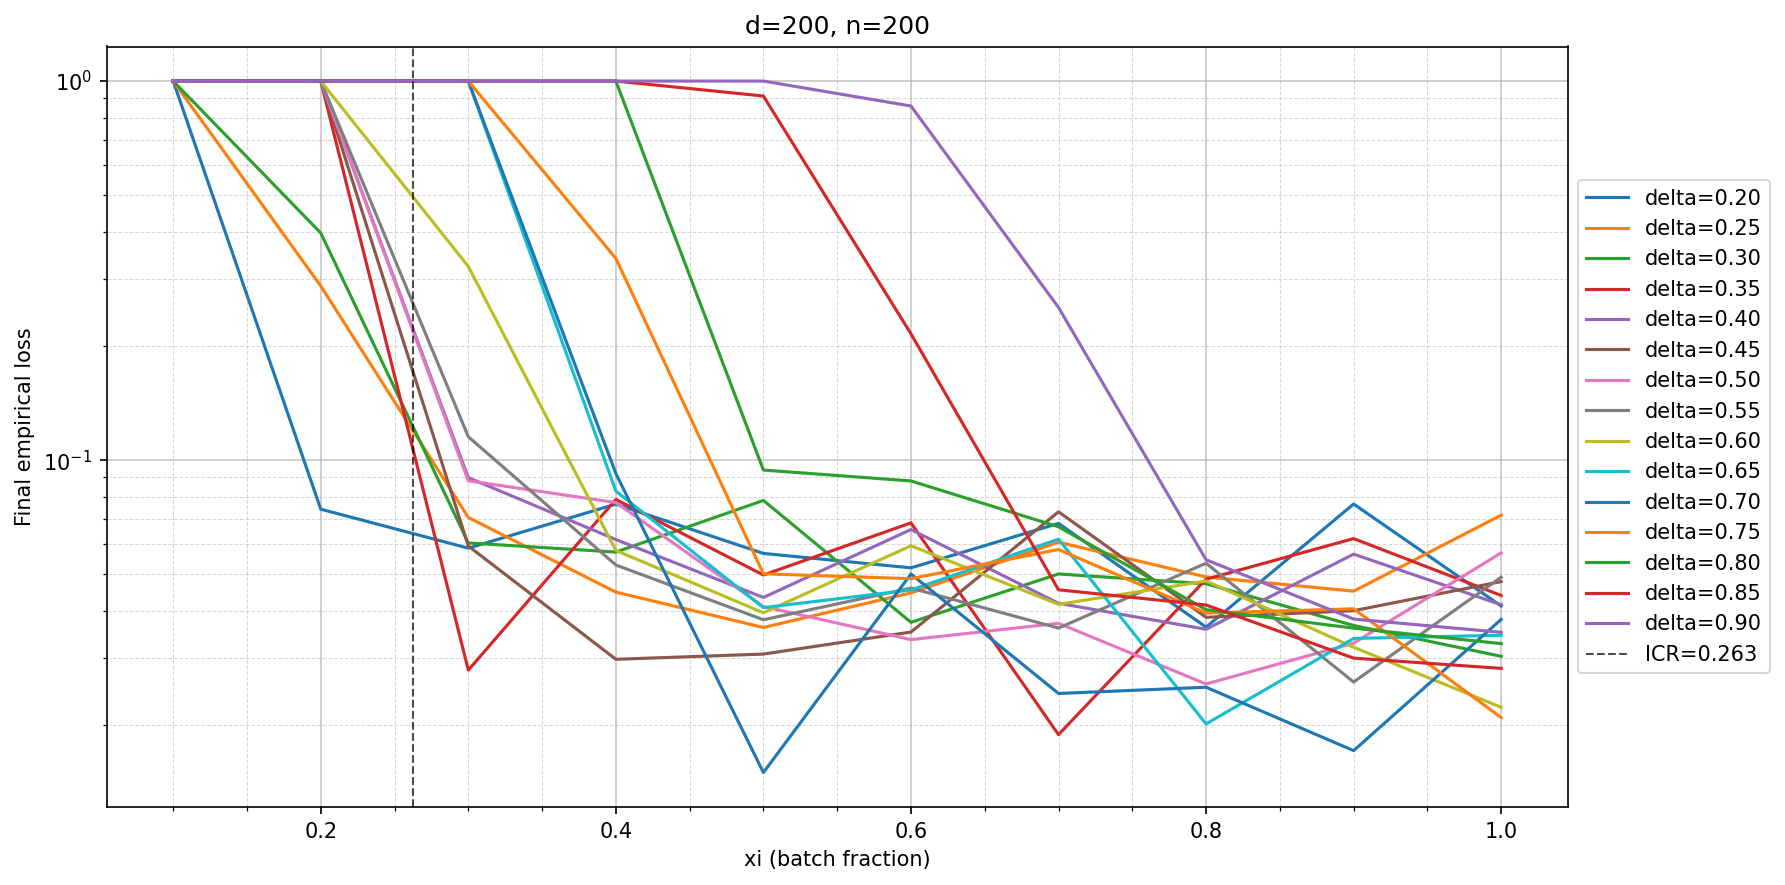

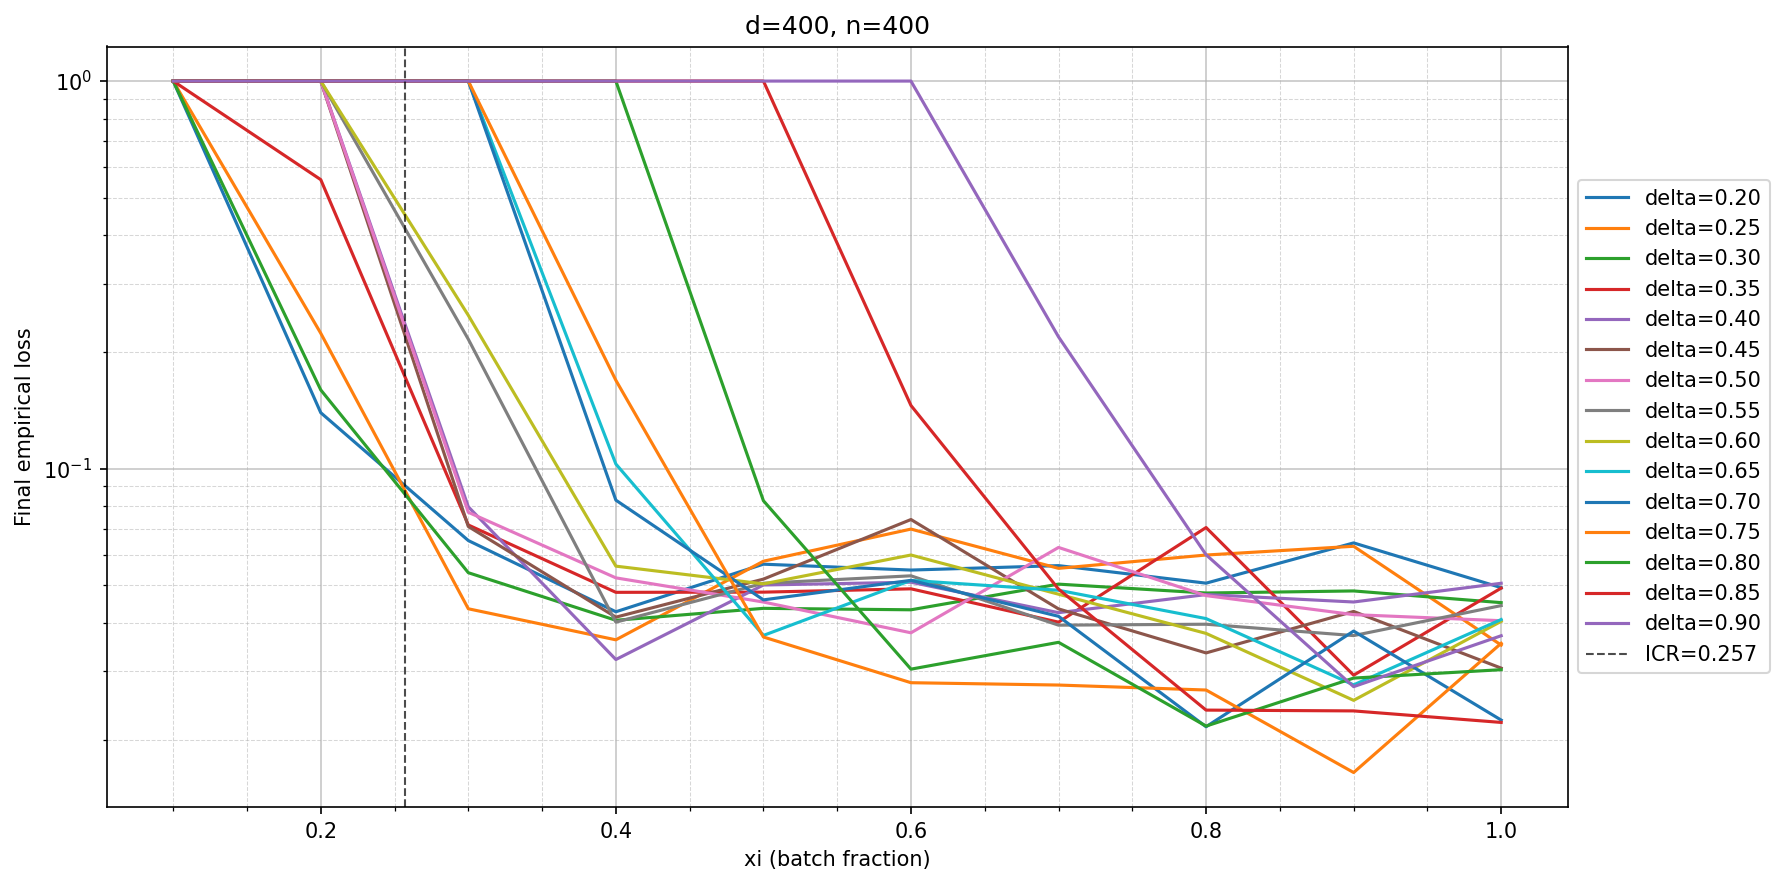

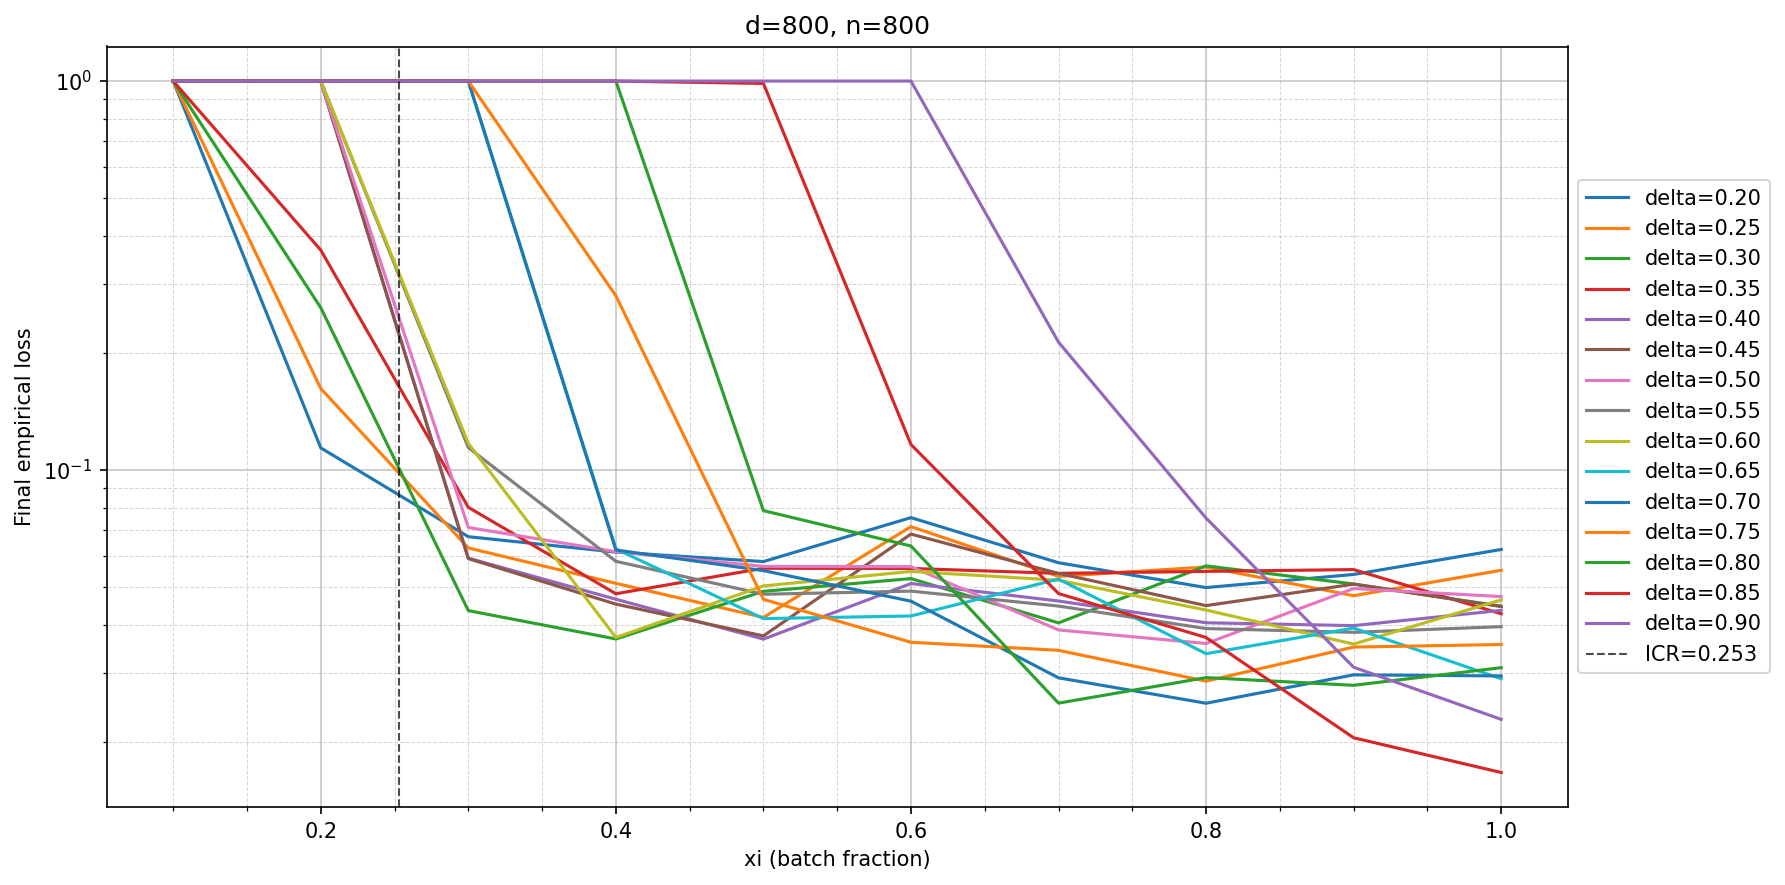

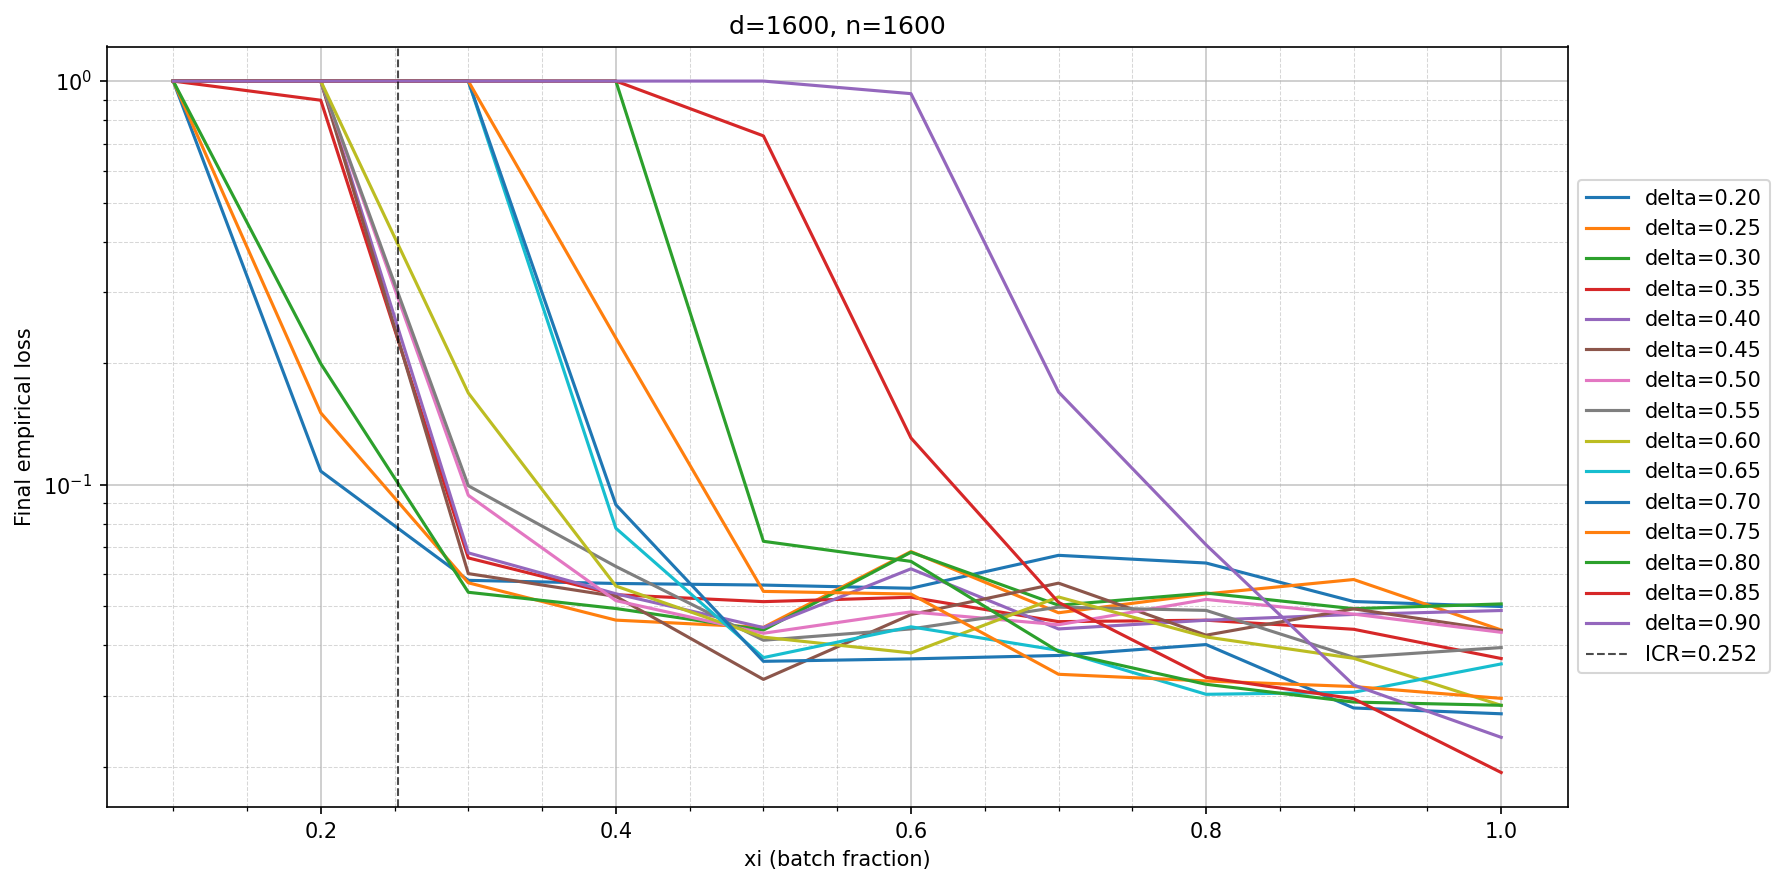

In [141]:
#d_list = [100]
delta_list = np.linspace(0.2, 0.9, 15)  # 15 values from 0.2 to 0.9
xi_list = np.linspace(0.1, 1.0, 10)     # 50 values from 0.1 to 1.0
main.estimate_threshold(
    d_list=d_list,
    delta_list=delta_list,
    xi_list=xi_list,
    rho=rho,
    num_epochs=num_epochs,
    gamma=lambda d: d,
    step_type="max"
)